## Bias-Variance Implementation

In [ ]:
# importing the libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor

In [2]:
np.random.seed(42)
def f(x):
    return np.sin(x)

X = np.linspace(0, 2 * np.pi, 200).reshape(-1, 1)
y_true = f(X).ravel()
noise_std = 0.3
n_datasets = 100
n_samples = 50

In [3]:
depths = range(1, 16)

all_predictions = []

for depth in depths:
    predictions = []

    for _ in range(n_datasets):

        X_train = np.random.uniform(0, 2 * np.pi, n_samples).reshape(-1, 1)
        y_train = f(X_train).ravel() + np.random.normal(
            0, noise_std, n_samples
        )

        # decision tree
        model = DecisionTreeRegressor(
            max_depth=depth,
            random_state=42
        )

        model.fit(X_train, y_train)

        # prediction
        predictions.append(model.predict(X))

    all_predictions.append(np.array(predictions))

In [4]:
bias_squared = []
variance = []
total_error = []

for predictions in all_predictions:
    
    mean_prediction = np.mean(predictions, axis=0)

    bias_sq = np.mean((mean_prediction - y_true) ** 2)       # bias squared

    var = np.mean(                                           # variance
        (predictions - mean_prediction) ** 2
    )

    error = np.mean(
        (predictions - y_true) ** 2
    )

    bias_squared.append(bias_sq)
    variance.append(var)
    total_error.append(error)

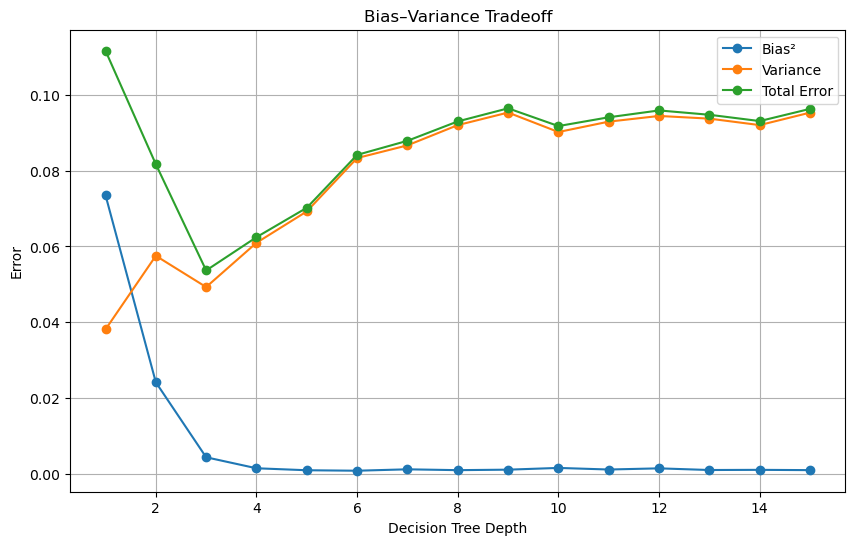

In [5]:
plt.figure(figsize=(10, 6))

plt.plot(depths, bias_squared, marker="o", label="Bias²")
plt.plot(depths, variance, marker="o", label="Variance")
plt.plot(depths, total_error, marker="o", label="Total Error")

plt.xlabel("Decision Tree Depth")
plt.ylabel("Error")
plt.title("Bias–Variance Tradeoff")
plt.legend()
plt.grid(True)

plt.show()